In [ ]:
# code used *Evolutionary Insights into Elongation Factor G Using AlphaFold and Ancestral Analysis*.  
**Comput Biol Med 2025 Vol. 191 Pages 110188; Accession Number: 40222265 DOI: 10.1016/j.compbiomed.2025.110188

# most the cells can be used independently with custom input. 

In [ ]:
# citations
# run with colabfold 1.5.5 from : https://github.com/sokrypton/ColabFold (Mirdita, M., Schutze, K., Moriwaki, Y., Heo, L., Ovchinnikov, S., and Steinegger, M. (2022). ColabFold: making protein folding accessible to all. Nat Methods 19, 679-682. 10.1038/s41592-022-01488-1.)
# followed clustering algorithm from : https://github.com/HWaymentSteele/AF_Cluster (Wayment-Steele, H.K., Ojoawo, A., Otten, R., Apitz, J.M., Pitsawong, W., Homberger, M., Ovchinnikov, S., Colwell, L., and Kern, D. (2024). Predicting multiple conformations via sequence clustering and AlphaFold2. Nature 625, 832-839. 10.1038/s41586-023-06832-9.)

In [1]:
#1 set consistent directions.
import os
import shutil
import glob
default_path = "/home/yuhong/G_Fold"
##########################################################################################2
COLAB = "/home/yuhong/colabfold/localcolabfold/colabfold-conda/bin/colabfold_batch"
SEQ = os.path.join(default_path,"SEQ")
os.makedirs(SEQ, exist_ok=True)
###########################################################################################
##########################################################################################3
# set the right a3m to cluster. should have just one in the folder
a3m_files = glob.glob(os.path.join(SEQ, "*.a3m"))
input_path = os.path.join(default_path,"Cluster")
os.makedirs(input_path, exist_ok=True)
###########################################################################################
##########################################################################################4
# define input and output file path 
a3m_path = os.path.join(input_path,"folding")
os.makedirs(a3m_path, exist_ok=True)
# Set the size threshold (4 KB)
size_threshold = 4 * 1024  # 4 KB for automatic operation. Choose based on sequence length. 
###########################################################################################
##########################################################################################5
# Define the log file path, CSV path, PDB directories, and threshold
log_file_path = os.path.join (a3m_path,"log.txt")  # Replace with the actual path
csv_output_path = os.path.join(a3m_path,"pLDDT.csv")  # Path for the output CSV file
pLDDT_threshold = 60  # Set your threshold for pLDDT
pdb_source_dir = a3m_path  # Directory containing the PDB files
pdb_target_dir = os.path.join(a3m_path,"sel_pdb")  # Directory to move selected PDB files
os.makedirs(pdb_target_dir, exist_ok=True)
###########################################################################################
##########################################################################################6 
residue_range1 = "1-286" # make sure only set value onsite
first_PSE_folder = os.path.join(pdb_target_dir,f"1st_{residue_range1}_RMSD")
os.makedirs(first_PSE_folder, exist_ok=True)                                
first_PSE = os.path.join(first_PSE_folder,f"1st_{residue_range1}_RMSD.pse")                         
###########################################################################################
##########################################################################################7
session_path = first_PSE  # direct run from the saved pse file.
rmsd_references = ["EX_175", "EX_276"]  # List of reference PDBs (without .pdb extension)
###########################################################################################
###########################################################################################8
plddt_file = os.path.join(a3m_path,"pLDDT.csv") # make sure the exact column heads. 
selected_headers = ['EX_175', 'EX_276']
############################################################################################
###########################################################################################9
a3m_directory = input_path
list1_path = os.path.join(os.path.dirname(session_path),"WT_list1.txt")
list2_path = list2_path = list1_path.replace("WT_list1.txt", "WT_list2.txt")
prefix = os.path.basename(list1_path).split('_')[0]
final_combined_a3m = os.path.join(os.path.dirname(list1_path), f"{prefix}_ForTree.fasta")
###########################################################################################
##########################################################################################10
# fetch the protein ID with the previous output.
TAX_FA = final_combined_a3m.replace(".fasta","_TAX.fa")
###########################################################################################
#########################################################################################11
#TAX_FA = final_combined_a3m.replace(".fasta","_TAX.fa")
###########################################################################################
##########################################################################################12
# same input TAX_FA
###########################################################################################
##########################################################################################13
#define tree methods.
###########################################################################################
###########################################################################################14
TAX_Shortened_FAS = TAX_FA.replace(".fa","_shortened.fas")  

###########################################################################################
#########################################################################################14b
directory_for_tree =os.path.dirname(TAX_Shortened_FAS) # all in the same folder of "first_PSE_folder"
##########################################################################################
##########################################################################################15
# Path to the directory containing .treefile files
directory_path = os.path.dirname(TAX_Shortened_FAS) # all in the same folder of "first_PSE_folder"
###########################################################################################
##########################################################################################16
# Path to the directory containing .treefile files
directory_path = os.path.dirname(TAX_Shortened_FAS) # all in the same folder of "first_PSE_folder"
###########################################################################################
#########################################################################################17
#it generates 1-unique, 2-unique, 1/2-common; then continue with 3 to generate 3x3 more txt, and so on.
# For files with 0Kb, or other threshold, it will not get into the next round of clustering. 
# refer to Figures S4 and S10 in  
##########################################################################################
########################################################################################18
# input folder is first_PSE_folder
node_branch_csv = os.path.join(first_PSE, "internal_nodes_distances.csv")
##########################################################################################
########################################################################################19        
disfile = node_branch_csv
node_thr = 1.8
matrix_dir = os.path.join(first_PSE_folder, "matrix")
##########################################################################################
########################################################################################20
output_jsd_folder = os.path.join(matrix_dir, "JSD") # matrix_dir  
final_output_filename = os.path.join(output_jsd_folder, "node_JSD.csv")
##########################################################################################
########################################################################################21
# Define the path to the saved JSD matrix
node_jsd_path = os.path.join(output_jsd_folder, "node_JSD.csv")

# Load the saved JSD matrix. this is more reliable to read the .csv, which can be slow for large node list. 
if os.path.exists(node_jsd_path):
    node_jsd = pd.read_csv(node_jsd_path, index_col=0)  # Load as DataFrame
    print("✅ Successfully loaded node_JSD matrix without recomputing!")

    # Fix NaN values in the diagonal by replacing them with 1
    np.fill_diagonal(node_jsd.values, 1)

    # Overwrite the original file with the fixed matrix
    node_jsd.to_csv(node_jsd_path)
    print(f"✅ Fixed and saved node_JSD matrix to: {node_jsd_path}")

else:
    print(f"⚠️ File not found: {node_jsd_path}")

##########################################################################################
########################################################################################22
#clustered_csv = hierarchical_clustering(node_jsd_path)[0] from 21
##########################################################################################
########################################################################################23
logo_dir = "/home/yuhong/LOGO"  # Path containing aligned sequences
valid_extension = ".fasta"  # Specify the desired extension to process
start_pos = 1  # Start position (1-based index)
end_pos = -1   # End position (inclusive, set to -1 for end of sequence)
chunk_size = 40  # Size of each fragment
width = 0.5  # Width of each letter; less than 1.0 increases spacing between letters
font_weight = 'light'  # Font weight for the letters ('light', 'normal', 'bold', etc.)
##########################################################################################


⚠️ File not found: /home/yuhong/G_Fold/Cluster/folding/sel_pdb/1st_1-286_RMSD/matrix/JSD/node_JSD.csv


In [ ]:
#2 move query sequence into SEQ then run colabfold
# path of colabfold_batch is: /home/yuhong/colabfold/localcolabfold/colabfold-conda/bin/colabfold_batch
#set short reference to colabfold_batch
import os
###########################################################################################
COLAB = "/home/yuhong/colabfold/localcolabfold/colabfold-conda/bin/colabfold_batch"
SEQ = os.path.join(default_path,"SEQ")
os.makedirs(SEQ, exist_ok=True)
###########################################################################################
!$COLAB --num-recycle 3 --num-models 3 --max-seq 1024 --max-extra-seq 10 {SEQ} {SEQ}

In [ ]:
#3 cluster .a3m in SEQ/. Then move them into Cluster
# need ClusterMSA_min3.py and utils.py ; both in default_path
import os
import glob
##########################################################################################3
# set the right a3m to cluster. should have just one in the folder
a3m_files = glob.glob(os.path.join(SEQ, "*.a3m"))
if a3m_files:
    a3m_for_cluster = a3m_files[0]  # Select the first file
    print(f"Selected A3M file for clustering: {a3m_for_cluster}")
else:
    print("No .a3m files found in SEQ/")
# The clustered a3m moved to {default_path}/Cluster, which will be input for the folding and pdb sorting. 
input_path = os.path.join(default_path,"Cluster")
os.makedirs(input_path, exist_ok=True)
#############################################################################################
!python $default_path/ClusterMSA_min3.py EX -i {a3m_for_cluster} -o {input_path}  --log_dir {input_path}

In [ ]:
#4. source input_path = os.path.join(default_path,"Cluster")
# new path in this cell: a3m_path = os.path.join(input_path,"folding")
#move random chosen half to fold. This is not necessary when commputing with GPU later on. 

import os
import shutil
##########################################################################4
# define input and output file path 
a3m_path = os.path.join(input_path,"folding")
os.makedirs(a3m_path, exist_ok=True)
# Set the size threshold (4 KB)
size_threshold = 4 * 1024  # 4 KB for automatic operation. Choose based on sequence length. 
#########################################################################

# Iterate through each file in the folder
for filename in os.listdir(input_path):
    # Check if the file is a .a3m file
    if filename.endswith(".a3m"):
        file_path = os.path.join(input_path, filename)
        # Get the size of the file in bytes
        file_size = os.path.getsize(file_path)
        # If the file size is less than the threshold, remove the file
        if file_size >= size_threshold:
            print(f"moving {filename} (Size: {file_size} bytes)")
            shutil.move(file_path, os.path.join(a3m_path, filename))

print("move complete!")

# folding all these a3m files. 
!$COLAB {a3m_path} {a3m_path} --num-models 1 --max-seq 1024

In [ ]:
#5. make selected pdb with pLDDT > threshold. If pLDDT already exist, skip the extracting step. 
# searching for best pLDDT > threshold, then move those into sel_pdb folder. 

import os
import shutil
import pandas as pd
import re
import csv

##########################################################################################################5
# Define the log file path, CSV path, PDB directories, and threshold
log_file_path = os.path.join (a3m_path,"log.txt")  # Replace with the actual path
csv_output_path = os.path.join(a3m_path,"pLDDT.csv")  # Path for the output CSV file
pLDDT_threshold = 68  # Set your threshold for pLDDT
pdb_source_dir = a3m_path  # Directory containing the PDB files
pdb_target_dir = os.path.join(a3m_path,"sel_pdb")  # Directory to move selected PDB files
os.makedirs(pdb_target_dir, exist_ok=True)
#############################################################################################################

def process_and_move_pdb_files(source_dir, target_dir, threshold_val, log_path, csv_path):
    # If CSV already exists, skip log parsing
    if not os.path.exists(csv_path):
        print("pLDDT.csv not found. Extracting from log.txt...")

        with open(log_path, 'r') as log_file:
            lines = log_file.readlines()

        extracted_data = []

        for i, line in enumerate(lines):
            if "rank_001" in line:
                pLDDT_match = re.search(r'pLDDT=([\d.]+)', line)
                if pLDDT_match:
                    pLDDT_value = float(pLDDT_match.group(1))
                    for j in range(i, -1, -1):
                        if "Query" in lines[j]:
                            ex_match = re.search(r'(EX_\w{3})', lines[j])
                            if ex_match:
                                ex_code = ex_match.group(0)
                                extracted_data.append([ex_code, pLDDT_value])
                                break

        with open(csv_path, 'w', newline='') as csv_file:
            writer = csv.writer(csv_file)
            writer.writerow(['EX_Code', 'pLDDT_Value'])
            writer.writerows(extracted_data)

        print(f"Extracted data saved to {csv_path}")
    else:
        print("pLDDT.csv already exists. Skipping log.txt processing.")

    # Load and process the CSV
    df = pd.read_csv(csv_path)
    sorted_df = df.sort_values(by='pLDDT_Value', ascending=False)
    truncated_df = sorted_df[sorted_df['pLDDT_Value'] >= threshold_val]

    truncated_csv_path = os.path.join(target_dir, "pLDDT_truncated.csv")
    truncated_df.to_csv(truncated_csv_path, index=False)
    print(f"Filtered pLDDT values saved to: {truncated_csv_path}")

    # Move and rename corresponding PDBs
    for _, row in truncated_df.iterrows():
        ex_code = row['EX_Code']
        matched = False
        for file_name in os.listdir(source_dir):
            if file_name.startswith(f"{ex_code}_unrelaxed_rank_001"): 
                source_path = os.path.join(source_dir, file_name)
                target_path = os.path.join(target_dir, f"{ex_code}.pdb")
                shutil.move(source_path, target_path)
                print(f"Moved and renamed: {file_name} -> {ex_code}.pdb")
                matched = True
                break
        if not matched:
            print(f"File not found for EX code: {ex_code}")

    print("PDB file processing complete.")

# Run it
process_and_move_pdb_files(pdb_source_dir, pdb_target_dir, pLDDT_threshold, log_file_path, csv_output_path)


In [ ]:
#6 load all pdbs in the default_path (or in subfolders if contain pdbs) to pymol2, align with ref in a range.This is more efficient because 
# almost prefectly aligned. so the RMSD reflects more on the true divergences in other ranges. 
# save the new pdbs coordinates in the
#pse. and in a new subfolder: /aligned. then output the RMSD.
# need to install pymol. 

import os
import pymol2
import numpy as np
import pandas as pd
import subprocess
############################################################################### 6 
residue_range1 = "1-286" # change range if need
NameOfFolder = f"1st_{residue_range1}_RMSD"# make a subfolder and pse and RMSD all named the same in the folder.
# pdb_target_dir = os.path.join(a3m_path,"sel_pdb")  # Directory to move selected PDB files
###############################################################################


def find_reference_pdb(parent_folder):
    """Locate the reference PDB file by searching in the parent folder and its subfolders."""
    
    PDB_list_path = os.path.join(parent_folder, "pLDDT_truncated.csv")
    try:
        REF_pdb_base = subprocess.run(
            f"tail -n +2 {PDB_list_path} | head -n 1 | cut -d, -f1",
            shell=True, text=True, capture_output=True, check=True
        ).stdout.strip()

        if not REF_pdb_base:
            print("Error: No valid reference PDB found in pLDDT_truncated.csv.")
            return None

        REF_pdb_name = REF_pdb_base + ".pdb"
        REF_pdb_path = os.path.join(parent_folder, REF_pdb_name)

        if os.path.exists(REF_pdb_path):
            return REF_pdb_path

        pdb_prefix = REF_pdb_base.split("_")[0]
        for root, _, files in os.walk(parent_folder):
            if os.path.basename(root).startswith(pdb_prefix):
                for file in files:
                    if file == REF_pdb_name:
                        return os.path.join(root, file)

        print(f"Error: Reference PDB {REF_pdb_name} not found in parent folder or subfolders.")
        return None

    except subprocess.CalledProcessError:
        print("Error: Could not extract reference PDB from pLDDT_truncated.csv.")
        return None


def load_and_align_pdbs(parent_folder, resi_range):
    """
    Load all PDB files from the parent folder (or subfolders), align them to a reference PDB,
    save the new coordinates in a subfolder /aligned, and calculate the RMSD matrix only for PDBs in the /aligned folder.
    """
    
    REF_pdb = find_reference_pdb(parent_folder)
    if REF_pdb is None:
        return None, None

    REF_pdb_base = os.path.basename(REF_pdb).replace(".pdb", "")

    with pymol2.PyMOL() as pymol:
        pymol.cmd.reinitialize()

        # Load reference PDB
        print(f"Loading reference PDB: {REF_pdb}")
        pymol.cmd.load(REF_pdb, "REF")
        pymol.cmd.select("REF_align", f"REF and resi {resi_range}")

        aligned_folder = os.path.join(default_path,f"1st_{residue_range1}_aligned_pdb")
        os.makedirs(aligned_folder, exist_ok=True)

        # Load all PDB files from parent folder and subfolders
        print("Searching for PDB files...")
        pdb_files = []
        for root, _, files in os.walk(parent_folder):
            for file_name in files:
                if file_name.endswith(".pdb"):
                    pdb_path = os.path.join(root, file_name)
                    obj_name = os.path.splitext(file_name)[0]
                    pymol.cmd.load(pdb_path, obj_name)
                    pdb_files.append(obj_name)
                    print(f"Loaded: {obj_name}")

        if not pdb_files:
            print("No PDB files found. Exiting...")
            return None, None

        # Align all PDBs to the reference
        print("Aligning PDB files...")
        for idx, obj_name in enumerate(pdb_files, start=1):
            pymol.cmd.cealign("REF_align",f"{obj_name} and resi {resi_range}")
            output_pdb_path = os.path.join(aligned_folder, f"{obj_name}.pdb")
            pymol.cmd.save(output_pdb_path, obj_name)
            print(f"Aligned {idx}/{len(pdb_files)}: {obj_name}, saved to {output_pdb_path}")

       # Remove reference from session
        pymol.cmd.delete("ref")
        pymol.cmd.delete("ref_align")


        # Save PyMOL session in a separate folder parallel to pdb path,same as the RMSD matrix.
        pse_folder = os.path.join(parent_folder,NameOfFolder)
        os.makedirs(pse_folder,exist_ok=True)
        pse_path = os.path.join(pse_folder, f"{NameOfFolder}.pse")
        pymol.cmd.save(pse_path)
        print(f"PyMOL session saved as: {pse_path}")

        return pse_path

# Run alignment
first_PSE = load_and_align_pdbs(pdb_target_dir, residue_range1)


In [ ]:
#7. calculate RMSD toward EX_276 and EX_175, the highest of the two major folding. 

import os
import pymol2
import numpy as np
import pandas as pd

##################################################################################7
try:
    session_path = first_PSE
except NameError:
    session_path = "/home/yuhong/G_Fold/Cluster/folding/sel_pdb/1st_1-286_RMSD/1st_1-286_RMSD.pse"  # direct run
rmsd_references = ["EX_175", "EX_276"]  # List of reference PDBs (without .pdb extension)
##################################################################################

def calculate_rmsd_from_pse(session_path, rmsd_references=None):
    """
    Loads a PyMOL session (.pse), extracts all PDB structures, and calculates RMSD 
    against a list of reference PDBs.

    Args:
        session_path (str): Full path to the PyMOL session (.pse) file.
        rmsd_references (list of str): List of reference object names (no path or extension).
    
    Output:
        Saves an RMSD matrix as a CSV file in the same directory as the .pse file.
    """

    session_path = os.path.abspath(session_path)
    session_dir = os.path.dirname(session_path)
    rmsd_output_path = os.path.join(session_dir, f"{os.path.basename(session_path).replace('.pse', '.csv')}")

    with pymol2.PyMOL() as pymol:
        pymol.cmd.reinitialize()
        print(f"Loading PyMOL session from: {session_path}")
        pymol.cmd.load(session_path)

        pdb_objects = pymol.cmd.get_object_list()
        print(f"Total objects in session: {len(pdb_objects)}")

        if not rmsd_references:
            rmsd_references = pdb_objects

        n = len(pdb_objects)
        m = len(rmsd_references)
        rmsd_matrix = np.zeros((n, m))

        print("Calculating RMSDs...")
        for i, obj1 in enumerate(pdb_objects):
            for j, obj2 in enumerate(rmsd_references):
                rmsd = pymol.cmd.rms_cur(obj1, obj2)
                rmsd_matrix[i, j] = rmsd
                print(f"RMSD {obj1} vs {obj2} = {rmsd:.3f}")

        # Use only names (no path or extension)
        row_labels = [os.path.basename(obj) for obj in pdb_objects]
        col_labels = [os.path.basename(ref) for ref in rmsd_references]

        rmsd_df = pd.DataFrame(rmsd_matrix, index=row_labels, columns=col_labels)
        rmsd_df.to_csv(rmsd_output_path)
        print(f"Saved RMSD CSV to: {rmsd_output_path}")
        return rmsd_output_path  # Return the CSV path

rmsd_matrix_file = calculate_rmsd_from_pse(session_path, rmsd_references)


In [ ]:
# 8. plot RMSD and color with pLDDT values. 
###########################################################################################8
plddt_file = os.path.join(a3m_path,"pLDDT.csv") # make sure the exact column heads. 
selected_headers = ['EX_175', 'EX_276']
############################################################################################
import pandas as pd
import os
import matplotlib.pyplot as plt

import pandas as pd
import os
import matplotlib.pyplot as plt

def plot_rmsd_vs_plddt(rmsd_matrix_file, plddt_file, selected_headers, x_range=None, y_range=None):
    """
    Plots RMSD values from an RMSD matrix file against two selected references, 
    with points colored based on pLDDT values. Matches IDs with or without '.pdb'.

    Args:
        rmsd_matrix_file (str): Path to the RMSD matrix CSV file.
        plddt_file (str): Path to the pLDDT CSV file.
        selected_headers (list of str): Two column names to use as x and y axes.
        x_range (tuple, optional): (min, max) values for the x-axis.
        y_range (tuple, optional): (min, max) values for the y-axis.
    
    Output:
        - Saves a merged CSV with pLDDT values.
        - Displays an RMSD scatter plot colored by pLDDT values.
    """

    # Load the CSV files
    plddt_df = pd.read_csv(plddt_file)
    rmsd_matrix_df = pd.read_csv(rmsd_matrix_file)

    # Ensure the selected headers exist
    if not all(header in rmsd_matrix_df.columns for header in selected_headers):
        raise ValueError(f"Selected headers {selected_headers} not found in RMSD matrix file.")

    # Select required columns from RMSD matrix
    columns_to_select = [rmsd_matrix_df.columns[0]] + selected_headers  # Always include the first column
    selected_rmsd_df = rmsd_matrix_df[columns_to_select]

    # Function to strip '.pdb' if present
    def strip_pdb(filename):
        return filename.replace('.pdb', '') if isinstance(filename, str) else filename

    # Apply stripping function to the first column of both files
    selected_rmsd_df.iloc[:, 0] = selected_rmsd_df.iloc[:, 0].apply(strip_pdb)
    plddt_df.iloc[:, 0] = plddt_df.iloc[:, 0].apply(strip_pdb)

    # Map pLDDT values to RMSD rows based on matching stripped names
    plddt_mapping = plddt_df.set_index(plddt_df.columns[0])  # Create lookup table
    selected_rmsd_df['pLDDT'] = selected_rmsd_df.iloc[:, 0].map(plddt_mapping.iloc[:, 0])

    # Save the new CSV
    output_file = os.path.join(os.path.dirname(rmsd_matrix_file), 'RMSD_REF.csv')
    selected_rmsd_df.to_csv(output_file, index=False)
    print(f'New CSV file saved as {output_file}')

    # Define RGB colors based on pLDDT value ranges
    def assign_color(value):
        if value >= 69.5:
            return 'darkblue'
        elif 59.5 <= value < 69.5:
            return 'red'
        elif 50 <= value < 60:
            return 'white'
        elif 40 <= value < 50:
            return 'white'
        else:
            return 'white'  # Default for missing or out-of-range values

    # Apply color assignment
    selected_rmsd_df['color'] = selected_rmsd_df['pLDDT'].apply(assign_color)

    x_range = (0, 30)
    y_range = (0, 30)

    plt.figure(figsize=(10, 6))
    plt.scatter(
        selected_rmsd_df[selected_headers[0]],  # X-axis
        selected_rmsd_df[selected_headers[1]],  # Y-axis
        c=selected_rmsd_df['color'],            # Colors based on pLDDT
        alpha=0.8, edgecolors='k'
    )

    if x_range:
        plt.xlim(x_range)
    if y_range:
        plt.ylim(y_range)

    plt.xlabel(selected_headers[0], fontsize=12)
    plt.ylabel(selected_headers[1], fontsize=12)
    plt.title('RMSD vs Reference Colored by pLDDT Value', fontsize=14)
    plt.grid(True)
    plt.show()



plot_rmsd_vs_plddt(rmsd_matrix_file, plddt_file, selected_headers,x_range=(0, 40), y_range=(0, 40))

In [ ]:
#9. pool list 1 and list 2 after RMSD clustering. 
# set the WT_list1 and WT_list2 via supervision, saving in the same folder as the RMSD. 
# save those into the sel_pdb folder. 
# combine .a3m in (/home/yuhong/demo/SEQ/Cluster): input_path 
# and save the combinded taged .a3m in the same folder as the lists.

import os
###########################################################################################9
a3m_directory = input_path
list1_path = os.path.join(os.path.dirname(session_path),"WT_list1.txt")
list2_path = list2_path = list1_path.replace("WT_list1.txt", "WT_list2.txt")
###########################################################################################

def combine_a3m_files(list_file_path, a3m_directory):
    """
    Combines sequences from .a3m files listed in a .txt file (which contains .pdb names).
    Saves combined output as a .a3m file in the same folder as the .txt file.
    """
    base_name = os.path.splitext(os.path.basename(list_file_path))[0]

    # Read .pdb names and convert to .a3m
    with open(list_file_path, 'r') as f:
        a3m_filenames = [line.strip().replace('.pdb', '.a3m') for line in f if line.strip()]

    combined = []
    for idx, fname in enumerate(a3m_filenames):
        fpath = os.path.join(a3m_directory, fname)
        if not os.path.exists(fpath):
            print(f"Warning: {fpath} not found. Skipping.")
            continue
        with open(fpath, 'r') as a3m_file:
            lines = a3m_file.readlines()
            combined.extend(lines if idx == 0 else lines[1:])  # Only keep header from first file

    # Write output .a3m file named after the list file
    out_path = os.path.join(os.path.dirname(list_file_path), f"{base_name}.a3m")
    with open(out_path, 'w') as out:
        for line in combined:
            if line.startswith('>'):
                out.write(f">{base_name}_{line[1:]}")
            else:
                out.write(line)

    print(f"Combined A3M file written to: {out_path}")
    return out_path

def create_final_combined_file(list1_path, list2_path, a3m_directory):
    """
    Combines the outputs of two list-based .a3m combinations into one final file.
    """
    a3m1 = combine_a3m_files(list1_path, a3m_directory)
    a3m2 = combine_a3m_files(list2_path, a3m_directory)

    prefix = os.path.basename(list1_path).split('_')[0]
    final_path = os.path.join(os.path.dirname(list1_path), f"{prefix}_ForTree.fasta")

    with open(final_path, 'w') as fout:
        with open(a3m1, 'r') as f1:
            fout.writelines(f1.readlines())
        with open(a3m2, 'r') as f2:
            fout.writelines(f2.readlines()[2:])  # Skip second file's first record

    print(f"Final combined A3M file created at: {final_path}")
    return final_path

# Run final combine
final_combined_a3m = create_final_combined_file(list1_path, list2_path, a3m_directory)


In [ ]:
#10. fetch protein ID from uniprot.org of the combined fasta. 

import requests
from Bio import SeqIO
import os
import glob

####################################################################################################################10
# fetch the protein ID with the previous output.
####################################################################################################################
# Function to fetch protein and organism information from UniProt, if the ID has
# no hit in uniprot, no save in the ourput for downstream analysis. 
def fetch_uniprot_data(uniref_id):
    url = f"https://rest.uniprot.org/uniprotkb/stream?query={uniref_id}&format=tsv&fields=protein_name,organism_name"
    headers = {"User-Agent": "Python script"}
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        lines = response.text.splitlines()
        if len(lines) > 1:
            data = lines[1].split("\t")
            if len(data) >= 2:
                protein_name = data[0]
                organism_name = data[1]
                print(f"Fetched data for {uniref_id}: {protein_name}, {organism_name}")
                return protein_name, organism_name
    else:
        print(f"Failed to fetch data for {uniref_id}. Status code: {response.status_code}")
        print("Response text:")
        print(response.text)
        
    print(f"No data found for {uniref_id}.")
    return None, None

# Function to update FASTA labels and exclude entries without UniProt data
def update_fasta_labels(input_file):
    print(f"Processing {input_file}...")
    records = list(SeqIO.parse(input_file, "fasta"))
    updated_records = []
    
    # Modify the description to replace underscores with dashes and fetch UniProt data
    for record in records:
        original_description = record.description
        
        # Look for UniRef100 ID and extract it
        if "UniRef100_" in original_description:
            uniref_id_part = original_description.split("UniRef100_")[-1].split()[0].strip()  # Extract the UniRef ID part
            
            # Fetch data from UniProt
            protein_name, organism_name = fetch_uniprot_data(uniref_id_part)
            
            # Only add records with valid UniProt data
            if protein_name and organism_name:
                record.description = f"{protein_name} [{organism_name}] | {record.description}"
                updated_records.append(record)
        else:
            print(f"No UniRef100 ID found in {record.id}, skipping.")
    
    # Write the updated records to the output file if there are any
    if updated_records:
        output_file = input_file.replace('.fasta', '_TAX.fa')
        SeqIO.write(updated_records, output_file, "fasta")
        print(f"Updated FASTA written to {output_file}")
    else:
        print(f"No valid records with UniProt data found in {input_file}.")
    return output_file

TAX_FA = update_fasta_labels(final_combined_a3m)


In [ ]:
#11 generate summary three columns: protein, taxon, uniref100 ID
# this is useful to set short names. 
import pandas as pd

###########################################################################################################11
# TAX_FA = final_combined_a3m.replace(".fasta","_TAX.fa")
############################################################################################################
def process_fasta_file(fasta_file):
    # Initialize lists to store the extracted information
    ids = []
    species_names = []
    descriptions = []

    # Read the fasta file line by line
    with open(fasta_file, 'r') as file:
        for line in file:
            if line.startswith('>'):
                # Extract the ID (first part before the first space or tab)
                id_part = line.split()[0]
                
                # Extract the species name (string between [])
                if '[' in line and ']' in line:
                    species_name = line[line.find('[')+1 : line.find(']')]
                else:
                    species_name = "Unknown"  # Handle cases where species is missing
                
                # Extract the description (string between the first space/tab and first [)
                if ' ' in line and '[' in line:
                    description = line.split(' ', 1)[1].split('[')[0].strip()
                else:
                    description = "No description"  # Handle cases where description is missing
                
                # Append extracted data to lists
                ids.append(id_part)
                species_names.append(species_name)
                descriptions.append(description)

    # Create a DataFrame
    data = {
        'ID': ids,
        'Species Name': species_names,
        'Description': descriptions
    }
    df = pd.DataFrame(data)

    # Generate the output CSV filename
    output_file = fasta_file.replace('.fa', '_summary.csv').replace('.fasta', '_summary.csv')

    # Save the DataFrame to a CSV file
    df.to_csv(output_file, index=False)
    print(f"CSV file saved as: {output_file}")

# Example usage
process_fasta_file(TAX_FA)  # Uses input_fa_file from previous cell.

In [ ]:
#12.This is to replace the long ID to shorter ones for itol coloring 

import os
import re
from Bio import SeqIO

#############################################################################################################12
# same input TAX_FA
#############################################################################################################
rename_conditions = {
    #"Drosophila": "umt", 
    "G-like protein ef-g2": "EF-G2",
   "elongation factor g 1": "EF-G1",
    "elongation factor g 2": "EF-G2",
    "tetracycline": "Tetra",
    "gtp-binding protein": "GtpB",
    "p-loop containing": "Ploop",
    "tr-type g": "TrG",
    "elongation factor g": "EFG",
    "elongation factor ef-g": "EFG",
    "elongation factor efg": "EFG",
    "EF-Tu": "Tu",
    "elongation factor Tu": "Tu",
    "EF-2": "EF2",
    "elongation factor 4": "EF4",
    # Add more conditions as needed
}

# Function to rename sequence ID based on conditions
def rename_sequence_id(sequence_id, rename_conditions):
    # Extract the original identifier after the last space, tab, or pipe
    # Split the ID into parts by space, tab, or pipe
    parts = re.split(r'[ \t|]+', sequence_id)
    # Get the last relevant part
    original_id = parts[-1]
    
    # Convert the sequence ID to lowercase for case-insensitive matching
    lower_seq_id = sequence_id.lower()
    
    # Initialize the prefix as empty
    prefix = ""
    
    # Check each condition in the rename_conditions dictionary
    for term, rename in rename_conditions.items():
        if term.lower() in lower_seq_id:
            prefix = rename
            break  # Stop at the first matching condition
    
    # Create the new short name
    if prefix:
        new_id = f"{prefix}-{original_id}"
    else:
        new_id = f"{original_id}"
    
    return new_id
    
# Automatically create the output file name by appending "_shortened.fa"
output_fa_file = os.path.splitext(TAX_FA)[0] + "_shortened.fas"

# Parse the input .fa file and rename sequence IDs
with open(output_fa_file, "w") as output_handle:
    for record in SeqIO.parse(TAX_FA, "fasta"):
        original_id = record.description
        new_id = rename_sequence_id(original_id, rename_conditions)
        record.id = new_id
        record.description = ""  # Remove the description after ID
        SeqIO.write(record, output_handle, "fasta")

print(f"Renamed sequences saved to {output_fa_file}")

In [ ]:
# 13, define tree methods.

# make phylo tree with iqtree2
def run_phylogenetic_tree(fas_file):
    base_name = os.path.splitext(fas_file)[0]
    # Command to run IQ-TREE for phylogenetic tree construction
    command = [
        'iqtree2',
        '-s', fas_file,
        '-m', 'TEST',
        '-bb', '1000',
        '-nt', 'AUTO',
        '--prefix', base_name
    ]
    subprocess.run(command)
    print(f"Phylogenetic tree constructed for {fas_file}")

# both tree
def run_phylogenetic_and_ancestral(fas_file):
    base_name = os.path.splitext(fas_file)[0]
    # Command to run IQ-TREE for phylogenetic tree construction
    phylo_command = [
        'iqtree2',
        '-s', fas_file,
        '-m', 'TEST',
        '-bb', '1000',
        '-nt', 'AUTO',
        '--prefix', base_name
    ]
    subprocess.run(phylo_command)
    print(f"Phylogenetic tree constructed for {fas_file}")

    # Command to run ancestral sequence reconstruction using the generated tree
    ancestral_command = [
        'iqtree2',
        '-s', fas_file,
        '-t', f"{base_name}.treefile",
        '-nt', 'AUTO',
        '--ancestral',
        '--prefix', f"{base_name}_anc"
    ]
    subprocess.run(ancestral_command)
    print(f"Ancestral sequences reconstructed for {fas_file}")


In [ ]:
#14 (check #14b for continuing on ancestral if interrupted. 
# Decide which process to run
import glob
import subprocess
import os
from Bio import SeqIO

###########################################################################################14
# Set up input and options
TAX_Shortened_FAS = TAX_FA.replace(".fa", "_shortened.fas")
min_length = 700  # Overwrite if needed
max_length = 710  # Overwrite if needed
analysis_type = input("Enter 'tree' to run only the phylogenetic tree, or 'both' to run both tree and ancestral reconstruction: ").strip().lower()
###########################################################################################

# Filter sequences by length
filtered_file = os.path.splitext(TAX_Shortened_FAS)[0] + "_filtered.fas"
error_file = os.path.splitext(TAX_Shortened_FAS)[0] + "_errors.txt"

valid_sequences = []
error_log = []

# Parse input FASTA and filter
for record in SeqIO.parse(TAX_Shortened_FAS, "fasta"):
    seq_length = len(record.seq)
    if min_length <= seq_length <= max_length:
        valid_sequences.append(record)
    else:
        error_log.append(
            f"ERROR: Sequence {record.id} contains {seq_length} characters, outside the range [{min_length}, {max_length}]"
        )

# Write outputs
SeqIO.write(valid_sequences, filtered_file, "fasta")
with open(error_file, "w") as ef:
    ef.write("\n".join(error_log))

print(f"Processed: {TAX_Shortened_FAS}")
print(f"Filtered sequences saved to: {filtered_file}")
print(f"Error log saved to: {error_file}\n")


if analysis_type == 'both':
    run_phylogenetic_and_ancestral(filtered_file)
elif analysis_type == 'tree':
    run_phylogenetic_tree(filtered_file)
else:
    print("Invalid input. Please enter 'tree' or 'both'.")

print("Requested analyses completed.")



In [ ]:
#14b. run ancestral tree if phylotree already exist.

import os
import subprocess
#########################################################################################14b
directory_for_tree =os.path.dirname(TAX_Shortened_FAS) # all in the same folder of "first_PSE_folder"
##########################################################################################
def find_filtered_treefile(directory):
    """Find the first *_filtered.treefile in the given directory."""
    for file_name in os.listdir(directory):
        if file_name.endswith("_filtered.treefile"): # specify your target treefile name.
            full_path = os.path.join(directory, file_name)
            print(f"Found treefile: {full_path}")
            return full_path  # Return the first match

    print("No *_filtered.treefile found in the directory.")
    return None  # Return None if no match is found

# Find the filtered tree file
tree_source = find_filtered_treefile(directory_for_tree)

if tree_source:
    # Extract base name and directory
    align_source = os.path.splitext(tree_source)[0] + ".fas"
    print(f"Using alignment file: {align_source}")

    def run_ancestral_only(tree_file, align_file):
        """Run ancestral reconstruction using the existing tree file."""
        tree_dir = os.path.dirname(tree_file)  # Ensure output is stored in the same directory
        base_name = os.path.splitext(os.path.basename(tree_file))[0]  # Get base filename
        output_prefix = os.path.join(tree_dir, f"{base_name}_anc")  # Add _anc prefix

        print(f"Using treefile: {tree_file} for ancestral sequence reconstruction...")
        print(f"Output will be saved as: {output_prefix}")

        # Run ancestral sequence reconstruction
        ancestral_command = [
            'iqtree2',
            '-s', align_file,   # Use alignment file
            '-t', tree_file,    # Use existing tree
            '-nt', 'AUTO',
            '--ancestral',
            '--prefix', output_prefix  # Save outputs in the same directory with _anc suffix
        ]
        subprocess.run(ancestral_command)
        print(f"Ancestral sequences reconstructed in {tree_dir}")

    # Run ancestral reconstruction only if a treefile was found
    run_ancestral_only(tree_source, align_source)
else:
    print("No tree file found. Exiting.")


In [ ]:
#15. # datasets for itol display of protein rings.
from Bio import Phylo

#########################################################################################15
# Path to the directory containing .treefile files
directory_path = os.path.dirname(TAX_Shortened_FAS) # all in the same folder of "first_PSE_folder"
#######################################################################################
# Define three different category_color mappings for proteins
category_colors_A = {
    "EF2": "#ff0000",  # red
    "EFG": "#c0c0c0",  # silver grey
}

category_colors_B = {
    "EF-G2": "#00ffff",  # cyan
    "Tetra": "#0000ff",  # blue
    "EF-G1":"#ffd700", #sunshine yellow
}

category_colors_C = {
    "Ploop": "#800080",  # purple
    "GtpB": "#00ff00",  # green
    "RF2": "#ffa500",  # orange
    "TrG": "#ff69b4",  # hot pink
}

def process_tree_file(tree_file, category_colors, dataset_label, output_suffix):
    tree = Phylo.read(tree_file, 'newick')

    # Note: Changed SEPARATOR to SPACE. Revert to TAB if SPACE is not supported by iTOL.
    dataset_content = (f'DATASET_COLORSTRIP\n'
                       f'SEPARATOR SPACE\n'
                       f'DATASET_LABEL {dataset_label}\n'
                       f'COLOR #ff0000\n'
                       f'DATA\n')

    for label in tree.get_terminals():
        label_name = label.name if label.name else ""
        color = '#ffffff'  # Default color
        for category, category_color in category_colors.items():
            if category in label_name:
                color = category_color
                break
        dataset_content += f'{label.name} {color}\n'

    # Define the output file path
    output_file_path = os.path.splitext(tree_file)[0] + output_suffix + '.txt'
    with open(output_file_path, 'w') as out_file:
        out_file.write(dataset_content)
    print(f"iTOL dataset file created: {output_file_path}")

def process_all_treefiles(directory):
    for filename in os.listdir(directory):
        if filename.endswith('filtered.treefile'):
            tree_file_path = os.path.join(directory, filename)
            print(f"Processing {tree_file_path}...")

            # Process for each category color mapping
            process_tree_file(tree_file_path, category_colors_A, "labelProA", "_itol_datasetA")
            process_tree_file(tree_file_path, category_colors_B, "labelProB", "_itol_datasetB")
            process_tree_file(tree_file_path, category_colors_C, "labelProC", "_itol_datasetC")


# Ensure the directory exists
if os.path.isdir(directory_path):
    process_all_treefiles(directory_path)
else:
    print("Invalid path or directory does not exist.")



In [ ]:
#16 generate the dataset for leave colors in itol.

#########################################################################################16
# Path to the directory containing .treefile files
directory_path = os.path.dirname(TAX_Shortened_FAS) # all in the same folder of "first_PSE_folder"
#######################################################################################
# Define conditions for label background colors
branch_colors_conditions = {
    "List1": "#ff0000",  # red
    "List2": "#00ff00",  # green
    "list1": "#ff0000",  # red
    "list2": "#00ff00",  # green
    "-1-": "#FF0000",    # red
    "-2-": "#0000FF",    # blue
    "-3-": "#FFFF00",    # yellow
    "-4-": "#00FF00",    # green
    "-7-": "#FF00FF",    # magenta
    "-8-": "#00FFFF",    # cyan
    "-13-": "#FFA500",   # orange
    "-17-": "#800080",   # purple
    "-24-": "#008000",   # dark green
    "-28-": "#000080",   # navy blue
    "-37-": "#FF4500",   # orange-red
    "-137-": "#8B0000",  # dark red
    "-248-": "#4682B4",  # steel blue
    # Add more conditions as needed
}

def generate_itol_branch_colors(tree_file):
    """Generate an iTOL TREE_COLORS dataset for branch colors."""
    tree = Phylo.read(tree_file, 'newick')
    output_filename = os.path.splitext(tree_file)[0] + '_branch_colors.txt'
    
    with open(output_filename, 'w') as out_file:
        out_file.write("TREE_COLORS\n")
        out_file.write("#lines starting with a hash are comments and ignored during parsing\n")
        out_file.write("SEPARATOR SPACE\n")
        out_file.write("DATA\n")
        
        for clade in tree.find_clades():
            if clade.name:
                for keyword, color in branch_colors_conditions.items():
                    if keyword in clade.name:
                        # Write the branch color information, including style and width
                        # Format: NODE_ID branch COLOR normal 1
                        out_file.write(f"{clade.name} branch {color} normal 1\n")
                        break

    print(f"iTOL branch colors dataset generated: {output_filename}")

import os
import glob  # Import the glob module to use glob.glob()

def process_directory(directory):
    """Process all .treefile files in the specified directory to generate iTOL branch colors datasets."""
    for filename in os.listdir(directory):
        if filename.endswith('filtered.treefile'):
            tree_file = os.path.join(directory, filename)
            print(f"Processing {tree_file}...")
            generate_itol_branch_colors(tree_file)

# Ensure the directory exists and process the files
if os.path.isdir(directory_path):
    process_directory(directory_path)
else:
    print("Invalid path or directory does not exist.")


In [5]:
#17. pairwise comparison of msas to generate unique, and common clusters.

################################################################################
#it generates 1-unique, 2-unique, 1/2-common; then continue with 3 to generate 3x3 more txt, and so on.
# For files with 0Kb, or other threshold, it will not get into the next round of clustering. 
# refer to Figures S4 and S10 in Comput Biol Med 2025 Vol. 191 Pages 110188; Accession Number: 40222265 DOI: 10.1016/j.compbiomed.2025.110188 
################################################################################

from Bio import SeqIO
import os
import shutil  # Import shutil for file operations

def compare_sequence_files(file1_path, file2_path, output_dir):
    """
    Compare sequences between two files and output unique and common sequences.
    """
    file1_base = os.path.splitext(os.path.basename(file1_path))[0]
    file2_base = os.path.splitext(os.path.basename(file2_path))[0]

    # Parse sequences from both files
    file1_seqs = {record.id: record for record in SeqIO.parse(file1_path, "fasta")}
    file2_seqs = {record.id: record for record in SeqIO.parse(file2_path, "fasta")}

    # Determine common and unique sequences
    common_ids = set(file1_seqs.keys()) & set(file2_seqs.keys())
    unique_file1_ids = set(file1_seqs.keys()) - common_ids
    unique_file2_ids = set(file2_seqs.keys()) - common_ids

    # Ensure the output directory exists
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # File paths for output
    output_files = {
        'common': os.path.join(output_dir, f"{file2_base}{file1_base}.fasta"),  # Concatenated name
        'unique1': os.path.join(output_dir, f"{file1_base}.fasta"),  # Updated file1
        'unique2': os.path.join(output_dir, f"{file2_base}0.fasta"),  # Updated file2
    }

    # Write outputs
    for key, seq_ids in [('common', common_ids), ('unique1', unique_file1_ids), ('unique2', unique_file2_ids)]:
        output_path = output_files[key]
        with open(output_path, 'w') as output_handle:
            if key == 'unique1':
                SeqIO.write((file1_seqs[id_] for id_ in seq_ids), output_handle, "fasta")
            elif key == 'unique2':
                SeqIO.write((file2_seqs[id_] for id_ in seq_ids), output_handle, "fasta")
            else:
                SeqIO.write((file1_seqs[id_] for id_ in common_ids), output_handle, "fasta")

        # Remove empty files
        if os.path.getsize(output_path) == 0:
            os.remove(output_path)
            print(f"Deleted empty file: {output_path}")

    # Overwrite file1 with unique sequences for next comparison
    with open(file1_path, 'w') as output_handle:
        SeqIO.write((file1_seqs[id_] for id_ in unique_file1_ids), output_handle, "fasta")

    # Write a summary
    summary_file = os.path.join(output_dir, f"{file1_base}_{file2_base}_summary.txt")
    with open(summary_file, 'w') as f:
        f.write(f"Total sequences in {file1_base}: {len(file1_seqs)}\n")
        f.write(f"Total sequences in {file2_base}: {len(file2_seqs)}\n")
        f.write(f"Common sequences: {len(common_ids)}\n")
        f.write(f"Unique sequences in {file1_base}: {len(unique_file1_ids)}\n")
        f.write(f"Unique sequences in {file2_base}: {len(unique_file2_ids)}\n")

    print(f"Comparison completed for {file1_base} and {file2_base}. Outputs saved to {output_dir}.")

def process_files_in_rounds(file_list, base_folder):
    """
    Process files sequentially, comparing each file with all files in the previous round's folder,
    creating a new folder for each round.
    """
    round_number = 1

    # Use the first file as the initial reference
    initial_file = file_list.pop(0)
    current_round_folder = os.path.join(base_folder, f"Combine_Round{round_number}")
    os.makedirs(current_round_folder, exist_ok=True)
    shutil.copy(initial_file, os.path.join(current_round_folder, os.path.basename(initial_file)))

    while file_list:
        next_file = file_list.pop(0)
        next_file_name = os.path.basename(next_file)
        next_file_path = os.path.join(base_folder, next_file_name)

        # Create the folder for the next round
        next_round_folder = os.path.join(base_folder, f"Combine_Round{round_number + 1}")
        os.makedirs(next_round_folder, exist_ok=True)

        # Compare the new file with all files in the current round's folder
        for fasta_file in os.listdir(current_round_folder):
            if fasta_file.endswith('.fasta'):  # Only process FASTA files
                fasta_path = os.path.join(current_round_folder, fasta_file)
                compare_sequence_files(next_file_path, fasta_path, next_round_folder)

        # Update the new file path after it is overwritten with unique sequences
        next_file_path = os.path.join(next_round_folder, f"{os.path.splitext(next_file_name)[0]}.fasta")

        # Move to the next round
        current_round_folder = next_round_folder
        round_number += 1

# Example Usage
combine_folder = "/home/yuhong/demo/combine_All_MSA"  # Path to the Combine folder
file_list = [
    "/home/yuhong/demo/combine_All_MSA/1.fasta",
    "/home/yuhong/demo/combine_All_MSA/2.fasta",
    "/home/yuhong/demo/combine_All_MSA/3.fasta",
    "/home/yuhong/demo/combine_All_MSA/4.fasta",
    "/home/yuhong/demo/combine_All_MSA/7.fasta",
    "/home/yuhong/demo/combine_All_MSA/8.fasta",
]

process_files_in_rounds(file_list, combine_folder)


Deleted empty file: /home/yuhong/demo/combine_All_MSA/Combine_Round2/12.fasta
Comparison completed for 2 and 1. Outputs saved to /home/yuhong/demo/combine_All_MSA/Combine_Round2.
Deleted empty file: /home/yuhong/demo/combine_All_MSA/Combine_Round3/103.fasta
Comparison completed for 3 and 10. Outputs saved to /home/yuhong/demo/combine_All_MSA/Combine_Round3.
Deleted empty file: /home/yuhong/demo/combine_All_MSA/Combine_Round3/23.fasta
Comparison completed for 3 and 2. Outputs saved to /home/yuhong/demo/combine_All_MSA/Combine_Round3.
Deleted empty file: /home/yuhong/demo/combine_All_MSA/Combine_Round4/34.fasta
Comparison completed for 4 and 3. Outputs saved to /home/yuhong/demo/combine_All_MSA/Combine_Round4.
Deleted empty file: /home/yuhong/demo/combine_All_MSA/Combine_Round4/1004.fasta
Comparison completed for 4 and 100. Outputs saved to /home/yuhong/demo/combine_All_MSA/Combine_Round4.
Deleted empty file: /home/yuhong/demo/combine_All_MSA/Combine_Round4/204.fasta
Comparison completed

In [7]:
#18. calculate all nodes branch distance to the center after midpoint re-rooting,output the list. 
import os
import csv
from ete3 import Tree
import glob
##########################################################################18
# input folder is first_PSE_folder
###########################################################################
def extract_internal_nodes(anc_path):
   # Find the first anc.treefile
    ancfiles = glob.glob(os.path.join(anc_path, "*anc.treefile"))
    if not ancfiles:
        print(f"❌ No 'anc.treefile' file found in {anc_path}.")
        return

    ancfile = ancfiles[0]  # Take the first match
    if not os.path.exists(ancfile):
        print(f"❌ anc file not found: {ancfile}")
        return

    print(f"📂 Using anc tree: {ancfile}")

    tree = Tree(ancfile, format=1)
   
    # Reroot the tree at the midpoint
    tree.set_outgroup(tree.get_midpoint_outgroup())

    # Extract all internal nodes (exclude leaves)
    internal_nodes = [node for node in tree.traverse() if not node.is_leaf()]
    
    # Compute branch distances to the midpoint root
    node_distances = {node.name: tree.get_distance(node) for node in internal_nodes if node.name}

    # Define output CSV path
    output_csv = os.path.join(anc_path, "internal_nodes_distances.csv")
    
    # Save results to CSV
    with open(output_csv, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Node", "Distance_to_Midpoint"])
        for node, distance in node_distances.items():
            writer.writerow([node, distance])

    print(f"Internal node distances saved to: {output_csv}")
    return output_csv
    
# Example usage
node_branch_csv = extract_internal_nodes(first_PSE_folder)


📂 Using anc tree: /home/yuhong/G_Fold/Cluster/folding/sel_pdb/1st_1-286_RMSD/All_Combine_unique_TAX_shortened_filtered_anc.treefile
Internal node distances saved to: /home/yuhong/G_Fold/Cluster/folding/sel_pdb/1st_1-286_RMSD/internal_nodes_distances.csv


In [8]:
#19. extract transposed sequence file of nodes selected below a threshold from #18,  
import os
import glob
import pandas as pd
######################################################################################19        
disfile = node_branch_csv
node_thr = 1.8
######################################################################################
def generate_node_list(csv_path, dis_thr):
    """
    Filters nodes based on a distance threshold and saves the result in a text file.

    Parameters:
    - csv_path (str): Path to the CSV file.
    - dis_thr (float): Distance threshold for filtering.

    Returns:
    - list: Filtered node names.
    """
    # Read the CSV file
    df = pd.read_csv(csv_path)

    # Ensure correct column names
    df.columns = ["Node", "Distance_to_Midpoint"]
    
    # Remove "Node" from each element in the Node column
    df["Node"] = df["Node"].astype(str).str.replace("Node", "", regex=False)
    
    # Filter nodes where distance < dis_thr
    filtered_nodes = df[df["Distance_to_Midpoint"] < dis_thr]["Node"].tolist()

    # Format output
    node_list_str = f"node_list = {filtered_nodes}"

    # Save to a text file
    output_file = csv_path.replace(".csv", f"_nodes{dis_thr:.2f}.txt")  # Format threshold nicely
    with open(output_file, "w") as f:
        f.write(node_list_str)

    print(f"✅ Node list saved to: {output_file}")
    print(node_list_str)  # Print for reference

    return filtered_nodes  # Return the list instead of None

def extract_full_matrices(state_path, nodes):
    """
    Extracts the full probability matrix for each node from a .state file 
    and saves them as CSV files in the 'matrix' folder.
    """
    nodes = [f"Node{node}" for node in nodes]  # Format node names

    # Ensure the output directory exists
    matrix_dir = os.path.join(state_path, "matrix")
    os.makedirs(matrix_dir, exist_ok=True)
    
    # Find the first .state file
    statefiles = glob.glob(os.path.join(state_path, "*.state"))
    if not statefiles:
        print(f"❌ No 'state' file found in {state_path}.")
        return

    statefile = statefiles[0]  # Take the first match
    if not os.path.exists(statefile):
        print(f"❌ state file not found: {statefile}")
        return

    print(f"📂 Using state: {statefile}")

    # Read the file line by line
    with open(statefile, "r") as file:
        lines = file.readlines()

    for node in nodes:
        # Find the first occurrence of the exact node match
        node_index = next((i for i, line in enumerate(lines) if line.split("\t")[0] == node), None)
        if node_index is None:
            print(f"⚠️ No data found for {node}")
            continue

        # Read all lines for the given node (skip header)
        node_data = [line.strip().split("\t") for line in lines[node_index:] if line.split("\t")[0] == node]

        # Convert to DataFrame
        df = pd.DataFrame(node_data)

        # Ensure the DataFrame has enough columns (skip if not enough data)
        if df.shape[1] < 4:
            print(f"⚠️ Node {node} has insufficient columns, skipping...")
            continue

        # Convert numerical values from the fourth column onward
        df = df.iloc[:, 3:].apply(pd.to_numeric, errors="coerce")

        # Transpose the matrix
        df_transposed = df.T

        # Save transposed matrix **without headers**
        output_filename = os.path.join(matrix_dir, f"{node}_matrix_transposed.csv")
        df_transposed.to_csv(output_filename, index=False, header=False)
        print(f"✅ Saved: {output_filename} (Transposed)")

    print("🎉 All requested node CSV files generated successfully!")
    
# Generate node list
node_list = generate_node_list(disfile,node_thr)

# Pass the node list to extract_full_matrices
node_matrix = extract_full_matrices(first_PSE_folder, node_list)


✅ Node list saved to: /home/yuhong/G_Fold/Cluster/folding/sel_pdb/1st_1-286_RMSD/internal_nodes_distances_nodes1.80.txt
node_list = ['1', '11', '10', '12', '187', '194', '9', '13', '32', '188', '190', '195', '222', '228', '8', '14', '19', '33', '135', '189', '191', '196', '219', '223', '225', '229', '423', '660', '7', '15', '17', '20', '22', '34', '116', '136', '192', '197', '220', '224', '226', '230', '320', '424', '624', '661', '674', '681', '5', '16', '18', '21', '23', '29', '35', '111', '117', '137', '193', '198', '221', '227', '231', '279', '321', '417', '425', '522', '625', '654', '662', '666', '675', '680', '682', '6', '4', '24', '28', '30', '31', '36', '82', '112', '115', '118', '130', '138', '185', '199', '208', '232', '247', '280', '317', '322', '410', '418', '422', '426', '469', '523', '548', '626', '642', '655', '663', '665', '667', '676', '683', '703', '3', '25', '37', '73', '83', '97', '113', '114', '119', '129', '131', '133', '139', '186', '200', '209', '214', '233', '23

In [9]:
#20. compute pairwise similarity of internal nodes
# with JSD method. 
import os
import numpy as np
import pandas as pd
import glob
from scipy.spatial.distance import jensenshannon
##########################################################################20
output_jsd_folder = os.path.join(matrix_dir, "JSD") # matrix_dir  
final_output_filename = os.path.join(output_jsd_folder, "node_JSD.csv")
###########################################################################
def load_probability_matrix(file_path):
    """
    Load a node's probability matrix from a CSV file without headers.
    Assumes the file contains only raw probability values.
    
    Parameters:
    - file_path (str): Path to the probability matrix CSV file.

    Returns:
    - np.ndarray: Probability matrix (20 amino acids × sequence length).
    """
    df = pd.read_csv(file_path, header=None)  # Load CSV with no headers
    return df.values  # Return probability matrix as a NumPy array


def compute_jsd_matrix(input_dir, output_dir, final_output_file):
    """Compute pairwise Jensen-Shannon Divergence (JSD) and save site-specific matrices."""

    # Ensure the output directory exists
    try:
        os.makedirs(output_dir, exist_ok=True)
    except PermissionError:
        print(f"⚠️ Permission denied: Cannot write to {output_dir}. Using home directory instead.")
        output_dir = os.path.expanduser("~/JSD")  # Switch to home directory
        os.makedirs(output_dir, exist_ok=True)
        final_output_file = os.path.join(output_dir, "node_JSD.csv")

    # Find all probability matrix files
    files = glob.glob(os.path.join(input_dir, "Node*_matrix_transposed.csv"))
    if not files:
        raise FileNotFoundError(f"No node probability matrix files found in {input_dir}")

    node_names = [os.path.basename(f).replace("_matrix_transposed.csv", "") for f in files]
    probability_matrices = {node: load_probability_matrix(f) for node, f in zip(node_names, files)}

    num_positions = next(iter(probability_matrices.values())).shape[1]  # Sequence length
    final_jsd_matrix = pd.DataFrame(index=node_names, columns=node_names, dtype=float)

    # Compute JSD for each site
    position_jsd_matrices = []
    for k in range(num_positions):
        position_jsd_matrix = pd.DataFrame(index=node_names, columns=node_names, dtype=float)

        for i, node1 in enumerate(node_names):
            for j, node2 in enumerate(node_names):
                if i < j:
                    p_vector = probability_matrices[node1][:, k]
                    q_vector = probability_matrices[node2][:, k]
                    jsd_value = jensenshannon(p_vector, q_vector)
                    position_jsd_matrix.loc[node1, node2] = jsd_value
                    position_jsd_matrix.loc[node2, node1] = jsd_value

        # Save individual site JSD matrix
        position_file = os.path.join(output_dir, f"node_JSD_{k}.csv")
        position_jsd_matrix.to_csv(position_file)
        position_jsd_matrices.append(position_jsd_matrix)

    # Compute final average JSD matrix
    for i, node1 in enumerate(node_names):
        for j, node2 in enumerate(node_names):
            if i < j:
                mean_jsd = np.nanmean([pos.loc[node1, node2] for pos in position_jsd_matrices])
                final_jsd_matrix.loc[node1, node2] = mean_jsd
                final_jsd_matrix.loc[node2, node1] = mean_jsd

    # Save final JSD results
    final_jsd_matrix.to_csv(final_output_file)
    print(f"✅ Final JSD matrix saved to: {final_output_file}")

    return final_jsd_matrix

# Example usage

compute_jsd_matrix(matrix_dir, output_jsd_folder, final_output_filename)


KeyboardInterrupt: 

✅ Successfully loaded node_JSD matrix without recomputing!
✅ Fixed and saved node_JSD matrix to: /home/yuhong/G_Fold/Cluster/folding/sel_pdb/1st_1-286_RMSD/matrix/JSD/node_JSD.csv
✅ Clustered correlation summary saved as /home/yuhong/G_Fold/Cluster/folding/sel_pdb/1st_1-286_RMSD/matrix/JSD/node_JSD_cluster.csv
✅ Dendrogram plot saved as /home/yuhong/G_Fold/Cluster/folding/sel_pdb/1st_1-286_RMSD/matrix/JSD/dendrogram.png
🔹 Running Seaborn clustermap (which performs its own clustering)...


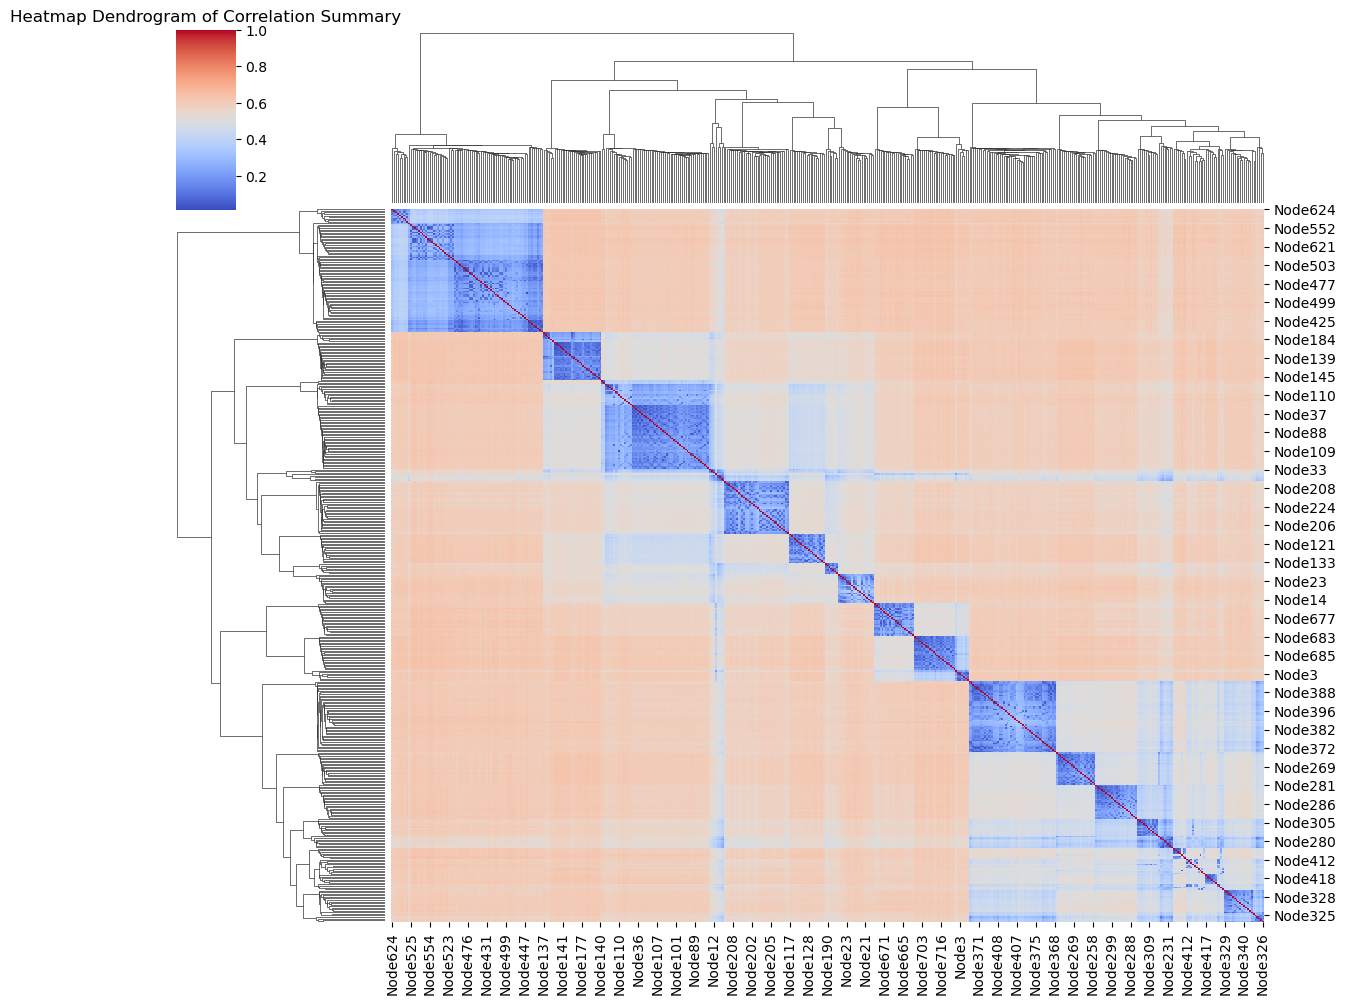

✅ Correlation summary heatmap saved as /home/yuhong/G_Fold/Cluster/folding/sel_pdb/1st_1-286_RMSD/matrix/JSD/correlation_summary.png


In [10]:
#21. use scipy Compute hierarchical clustering directly from df_summary (without squareform)

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import pdist
##########################################################################################21
# Define the path to the saved JSD matrix
node_jsd_path = os.path.join(output_jsd_folder, "node_JSD.csv")

# Load the saved JSD matrix. this is more reliable to read the .csv, which can be slow for large node list. 
if os.path.exists(node_jsd_path):
    node_jsd = pd.read_csv(node_jsd_path, index_col=0)  # Load as DataFrame
    print("✅ Successfully loaded node_JSD matrix without recomputing!")

    # Fix NaN values in the diagonal by replacing them with 1
    np.fill_diagonal(node_jsd.values, 1)

    # Overwrite the original file with the fixed matrix
    node_jsd.to_csv(node_jsd_path)
    print(f"✅ Fixed and saved node_JSD matrix to: {node_jsd_path}")

else:
    print(f"⚠️ File not found: {node_jsd_path}")

##########################################################################################
def hierarchical_clustering(JSD_input, plot_csv=True):
    """
    Perform hierarchical clustering on a correlation summary CSV file.

    Parameters:
    - JSD_input (str): Path to the CSV file containing correlation summary.
    - plot_csv (bool): Whether to generate a heatmap with dendrogram.

    Returns:
    - str: Path to the saved clustered CSV file.
    - str: Path to the saved dendrogram plot.
    """
    # Load CSV
    df_summary = pd.read_csv(JSD_input, index_col=0)

    # Compute hierarchical clustering directly from df_summary (without squareform)
    linkage_matrix = linkage(pdist(df_summary, metric='euclidean'), method='average')

    # Get the SciPy cluster order
    cluster_order = leaves_list(linkage_matrix)
    ordered_labels_scipy = df_summary.index[cluster_order].tolist()
    #print("🔹 SciPy Cluster Order:", ordered_labels_scipy)

    # Reorder the DataFrame based on clustering order
    clustered_df = df_summary.iloc[cluster_order, :].iloc[:, cluster_order]
    clustered_df.index = ordered_labels_scipy
    clustered_df.columns = ordered_labels_scipy

    # Save clustered CSV
    clustered_csv_filename = JSD_input.replace(".csv", "_cluster.csv")
    clustered_df.to_csv(clustered_csv_filename)
    print(f"✅ Clustered correlation summary saved as {clustered_csv_filename}")

    # Get the output directory
    subfolder = os.path.dirname(JSD_input)

    # Save dendrogram plot
    dendro_plot_filename = os.path.join(subfolder, "dendrogram.png")
    plt.figure(figsize=(10, 6))
    dendrogram(linkage_matrix, labels=ordered_labels_scipy, leaf_rotation=90, leaf_font_size=10)
    plt.title("Dendrogram of Correlation Summary Clustering")
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.savefig(dendro_plot_filename)
    plt.close()
    print(f"✅ Dendrogram plot saved as {dendro_plot_filename}")

    # Plot heatmap with dendrogram if plot_csv is True
    if plot_csv:
        print("🔹 Running Seaborn clustermap (which performs its own clustering)...")
        g = sns.clustermap(df_summary, method='average', cmap='coolwarm', figsize=(12, 10))

        # Extract Seaborn cluster order
        reordered_rows_seaborn = [df_summary.index[i] for i in g.dendrogram_row.reordered_ind]
        reordered_cols_seaborn = [df_summary.columns[i] for i in g.dendrogram_col.reordered_ind]

       # print("🔹 Seaborn Cluster Order (Rows):", reordered_rows_seaborn)
       # print("🔹 Seaborn Cluster Order (Columns):", reordered_cols_seaborn)

        plt.title("Heatmap Dendrogram of Correlation Summary")
        plot_filename = os.path.join(subfolder, "correlation_summary.png")
        plt.savefig(plot_filename)
        plt.show()
        print(f"✅ Correlation summary heatmap saved as {plot_filename}")

    return clustered_csv_filename, dendro_plot_filename

# Run clustering function
clustered_csv = hierarchical_clustering(node_jsd_path)[0]


In [ ]:
#22. plot the dendrogram (clustered_csv from 25d) with customer color palette. the original plot as shown. 
# and plot the off-diagnal transition curve of element(i-1, i). 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
##################################################################################22
#clustered_csv = hierarchical_clustering(node_jsd_path)[0] from 2
##################################################################################

def plot_clustered_heatmap(csv_file, color_map=None):
    """Plots a heatmap from a clustered CSV file with custom conditional coloring.
    
    Parameters:
    csv_file (str): Path to the clustered CSV file.
    color_map (list of tuples): Custom color conditions [(threshold, color), ...].
    """
    
    # Default color mapping if not provided
    if color_map is None:
        color_map = [
            (0.5, "#FFFFFF"),  # White for values >0.5
            (0.3, "#FFA500"),  # Orange for 0.3 - 0.5
            (0.0, "#FF0000")   # Red for < 0.3
        ]
    
    # Load the clustered CSV file
    df = pd.read_csv(csv_file, index_col=0)
    
    # Extract thresholds and colors
    thresholds, colors = zip(*sorted(color_map, key=lambda x: x[0]))  # Sort in ascending order
    
    # Define a colormap and corresponding normalization
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(boundaries=list(thresholds) + [1.0], ncolors=len(colors) + 1)
    
    # Plot heatmap with fixed color mapping
    plt.figure(figsize=(12, 10))
    sns.heatmap(df, annot=False, linewidths=0.5, cmap=cmap, norm=norm, cbar=True)
    plt.title("Clustered Heatmap with Custom Coloring")
    
    # Save plot
    custom_plot_filename = csv_file.replace(".csv", "_custom_heatmap.png")
    plt.savefig(custom_plot_filename)
    plt.show()
    print(f"✅ Custom heatmap saved as {custom_plot_filename}")
    
    return custom_plot_filename

def plot_standard_clustermap(csv_file):
    """Plots the saved clustered CSV using the default clustermap settings."""
    
    # Load the clustered CSV file
    df = pd.read_csv(csv_file, index_col=0)

    # Plot using seaborn clustermap
    plt.figure(figsize=(10, 8))
    g = sns.clustermap(df, method='average', cmap='coolwarm', figsize=(12, 10))
    plt.title("Heatmap Dendrogram of JSD Matrix")
    
    # Save plot
    clustermap_filename = csv_file.replace(".csv", "_clustermap.png")
    plt.savefig(clustermap_filename)
    plt.show()
    print(f"✅ Clustermap saved as {clustermap_filename}")

    return clustermap_filename

def plot_off_diagonal_curve(csv_file, threshold=0.4):
    """Plot the off-diagonal elements above the diagonal elements as a single curve.
    Identify clusters where off-diagonal values drop below the threshold.
    
    Parameters:
    csv_file (str): Path to the clustered CSV file.
    threshold (float): Cutoff value to define clusters.
    """
    
    # Load the CSV file as a DataFrame
    df = pd.read_csv(csv_file, index_col=0)
    
    # Convert all data to numeric
    df = df.apply(pd.to_numeric, errors='coerce')
    
    # Ensure the matrix is square
    if df.shape[0] != df.shape[1]:
        raise ValueError("The input matrix must be square.")
    
    # Extract the first off-diagonal elements (above the main diagonal)
    off_diagonal_values = [df.iloc[i, i+1] for i in range(min(df.shape[0]-1, df.shape[1]-1))]
    
    # Plot the curve
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(off_diagonal_values) + 1), off_diagonal_values, marker='o', linestyle='-')
    plt.xlabel("Index")
    plt.ylabel("Off-Diagonal Value")
    plt.title("Off-Diagonal Elements Curve")
    plt.grid()
    plt.show()
    
    # Identify clusters based on threshold
    cluster_list = []
    current_cluster = [df.index[0]]

    for i in range(len(off_diagonal_values)):
        if off_diagonal_values[i] > threshold:
            if i > 0 and off_diagonal_values[i - 1] > threshold:
                cluster_list.append(current_cluster)
                current_cluster = [df.index[i+1]]
            else:
                cluster_list.append(current_cluster)
                current_cluster = [df.index[i+1]]
        else:
            current_cluster.append(df.index[i+1])
    
    # Append the final cluster
    if current_cluster:
        cluster_list.append(current_cluster)
    
    # Save clusters to a text file
    txt_filename = csv_file.replace(".csv", f"_list{threshold}.txt")
    with open(txt_filename, "w") as f:
        for idx, cluster in enumerate(cluster_list):
            f.write(f"Cluster {idx+1}: {', '.join(cluster)}\n")
    
    print(f"✅ Cluster list saved as {txt_filename}")

# Run the heatmap and verification plots
custom_heatmap = plot_clustered_heatmap(clustered_csv, color_map=None)
clustermap_plot = plot_standard_clustermap(clustered_csv)
off_diagonal_value = plot_off_diagonal_curve(clustered_csv, 0.4)


In [ ]:
#23. logomaker.
# 1.this cell will make logo withOUT axis label, but enabling font and gap editing.
#X-ticks are displayed. 
# also the valid_extension enalbe selectivity for processing. 
# will make a final combined png in the order of the range. 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import AlignIO
import logomaker
from PIL import Image

###########################################################################23
logo_dir = "/home/yuhong/LOGO"  # Path containing aligned sequences
valid_extension = ".fasta"  # Specify the desired extension to process
start_pos = 1  # Start position (1-based index)
end_pos = -1   # End position (inclusive, set to -1 for end of sequence)
chunk_size = 40  # Size of each fragment
width = 0.5  # Width of each letter; less than 1.0 increases spacing between letters
font_weight = 'light'  # Font weight for the letters ('light', 'normal', 'bold', etc.)
###########################################################################

def create_sequence_logo(aligned_file, output_dir, start_pos, end_pos, width=0.5, font_weight='light'):
    """
    Create a sequence logo for a specified range of residues and save it as a PNG file.
    """
    try:
        alignment = AlignIO.read(aligned_file, "fasta")
        print(f"Successfully read alignment file {aligned_file}")
    except Exception as e:
        print(f"Error reading {aligned_file}: {e}")
        return None

    sequence_length = alignment.get_alignment_length()
    start_pos = max(0, start_pos - 1)
    end_pos = min(end_pos, sequence_length)

    valid_aa = set("ACDEFGHIKLMNPQRSTVWY-")
    fragment_alignment = []

    for record in alignment:
        seq = str(record.seq)[start_pos:end_pos]
        sanitized = ''.join([aa if aa.upper() in valid_aa else '-' for aa in seq])
        fragment_alignment.append(sanitized)
        try:
            fragment_df = logomaker.alignment_to_matrix(fragment_alignment, to_type='counts', characters_to_ignore='')
        except Exception as e:
            print(f"Error converting alignment to matrix: {e}")
            return None

    color_scheme = {
        'A': 'green', 'C': 'blue', 'D': 'red', 'E': 'red',
        'F': 'orange', 'G': 'orange', 'H': 'blue', 'I': 'green',
        'K': 'red', 'L': 'green', 'M': 'green', 'N': 'blue',
        'P': 'orange', 'Q': 'blue', 'R': 'red', 'S': 'orange',
        'T': 'orange', 'V': 'green', 'W': 'orange', 'Y': 'orange',
        '-': 'gray'
    }

    fig, ax = plt.subplots(figsize=(10, 6))
    logomaker.Logo(fragment_df, ax=ax, color_scheme=color_scheme, width=width, font_name='DejaVu Sans', font_weight=font_weight)
    ax.set_yticks([])  # Remove y-axis ticks
    ax.set_xticks(fragment_df.index[::2])
    ax.set_xticklabels(fragment_df.index[::2] + start_pos + 1)  # Adjust for correct numbering

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory {output_dir}")

    logo_path = os.path.join(output_dir, f"{os.path.basename(aligned_file)}_logo_{start_pos + 1}to{end_pos}.png")
    plt.tight_layout()
    plt.savefig(logo_path)
    plt.close()
    
    print(f"Saved logo to {logo_path}")
    return logo_path  # Return the path to include in the final combination


def combine_images_vertically(image_paths, output_path):
    """
    Combine images vertically and save the final combined image.
    """
    if not image_paths:
        print(f"⚠️ No images found for combination. Skipping {output_path}.")
        return

    images = [Image.open(img) for img in image_paths]
    max_width = max(img.width for img in images)
    total_height = sum(img.height for img in images) + (len(images) * 30)  # Add spacing

    combined_image = Image.new('RGB', (max_width, total_height), "white")
    y_offset = 0

    for img in images:
        combined_image.paste(img, (0, y_offset))
        y_offset += img.height + 30

    combined_image.save(output_path)
    print(f"✅ Combined image saved as: {output_path}")


def process_files_in_directory(directory_path, valid_extension='.fasta', start_pos=1, end_pos=-1, chunk_size=40, width=0.8, font_weight='light'):
    """
    Process specific aligned sequence files in the directory based on a chosen extension and create sequence logos.
    """
    fasta_files = [f for f in os.listdir(directory_path) if f.endswith(valid_extension)]
    print(f"Found {len(fasta_files)} {valid_extension} files in {directory_path}")

    if not fasta_files:
        print(f"No {valid_extension} files found in {directory_path}.")
        return

    all_combined_images = []

    for file_name in fasta_files:
        file_path = os.path.join(directory_path, file_name)
        base_name = os.path.splitext(file_name)[0]
        logo_output_dir = os.path.join(directory_path, base_name)
        
        try:
            alignment = AlignIO.read(file_path, "fasta")
            sequence_length = alignment.get_alignment_length()
            end_pos = end_pos if end_pos != -1 else sequence_length

            chunk_start = start_pos
            chunked_images = []

            while chunk_start <= end_pos:
                chunk_end = min(chunk_start + chunk_size - 1, end_pos)
                logo_path = create_sequence_logo(file_path, logo_output_dir, chunk_start, chunk_end, width, font_weight)
                
                if logo_path:
                    chunked_images.append(logo_path)
                
                chunk_start += chunk_size

            # Combine images for this specific file into blocks (1-40, 41-80, ...)
            if chunked_images:
                combined_output = os.path.join(logo_output_dir, f"{base_name}_combined.png")
                combine_images_vertically(chunked_images, combined_output)
                all_combined_images.append(combined_output)

        except Exception as e:
            print(f"Error processing file {file_path}: {e}")

    # Final step: Merge all combined block images into a final PNG
    if all_combined_images:
        final_output_path = os.path.join(directory_path, "final_combined_logo.png")
        combine_images_vertically(all_combined_images, final_output_path)
        print(f"✅ Final combined image saved: {final_output_path}")

    print("Processing complete.")


process_files_in_directory(logo_dir, valid_extension, start_pos, end_pos, chunk_size, width, font_weight)
